In [1]:
import torch
import vae_model 
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from tqdm.notebook import tqdm
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "STIXGeneral",
    "text.latex.preamble": r"\usepackage[utf8]{inputenc}\usepackage{amsmath}",
    "figure.figsize": [12, 4],  # ancho, Largo  
    "xtick.labelsize": 12,  # tamaño ticks en eje x
    "ytick.labelsize": 12   # tamaño ticks en eje y
})

Generar puntos usados para el encoder (training set )

In [2]:
bounds = torch.tensor([[1 , 1 , 1 , 30] ,
                       [60, 60, 60, 50]],dtype = torch.float64)
num_initial_points = 5000
initial_points = vae_model.data_encoder_generation(bounds , num_initial_points=num_initial_points)
print('Number of points generated:', len(initial_points))
# initial_points

Number of points generated: 5000


Load Model and updated the weights of the model with the file already saved and optimized.

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = vae_model.VariationalAutoencoder(emb_dim=71, hidden_dim = 115 , 
                                latent_dim=7).to(device)
checkpoint = torch.load('VAE_Intensified.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

VariationalAutoencoder(
  (feed1_emb): Embedding(60, 71)
  (feed2_emb): Embedding(60, 71)
  (stagesdw_emb): Embedding(60, 71)
  (stagescol_emb): Embedding(21, 71)
  (encoder_fc): Sequential(
    (0): Linear(in_features=284, out_features=115, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=115, out_features=57, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=57, out_features=28, bias=True)
  )
  (fc_mu): Linear(in_features=28, out_features=7, bias=True)
  (fc_logvar): Linear(in_features=28, out_features=7, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=7, out_features=28, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=28, out_features=57, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=57, out_features=115, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=115, out_features=284, bias=True)
  )
  (feed1_out): Linear(in_

Test if initial data can be reconstructed with accuracy and get bound for Z dimension.

In [4]:
# Get bounds of continuous latent space
z , min_bounds , max_bounds = vae_model.get_z_dimension(initial_points, model)

### Begin Bayesian Optimization algorithm

In [5]:
# Manipulated variables
#                       Re, S/F, Vr, F1, F2, NDWT, NCT 
bounds = torch.tensor([[2.0, 50 , 15 ,1 , 1 , 1, 30] ,
                       [5.0, 100, 100 , 50, 50, 50, 50]],dtype = torch.float64)
var_types = ['real', 'real', 'real', 'int', 'int', 'int', 'int']

# Get initial points
num_initial_points = 50
initial_points_BO = vae_model.population_generation(bounds, var_types , num_initial_points=num_initial_points)
print('Number of points generated:', len(initial_points_BO))

Number of points generated: 50


In [6]:
# Discrete variables, format must be changed to long or int type
continuos_initial_points = initial_points_BO[:, 0:3].numpy()
discrete_initial_points = torch.tensor(np.array(initial_points_BO[:, 3:]),dtype=torch.long)
converted_points = vae_model.transform_discrete(continuos_initial_points,
                             discrete_initial_points, model)

Sort data to avoid hugh differences between designs

In [7]:
initial_points_BO = initial_points_BO[initial_points_BO[:, -1].argsort(descending=False)]

Evaluate all points in Aspen 

In [8]:
output_nodes = [r"\Data\Streams\DCM\Output\MOLEFRAC\MIXED\DICHL-01"]       
listofcomponents = ['METHA-01','DICHL-01','N:N-D-01']
Application = vae_model.AspenSimulation_MOBO(aspen_file_path="Caso estudio intensificado.bkp",
                        output_nodes=output_nodes, listofcomponents=listofcomponents)
Application.connect()
# Evaluate the function at these initial points
initial_evals = torch.tensor(np.array([Application.run_simulation(point) for point in initial_points_BO]), dtype=torch.float64)
mask = initial_evals[:, 1] > -999
initial_evals = initial_evals[mask]
initial_points_BO = initial_points_BO[mask]
converted_points = converted_points[mask]
print('Max function value O.F 1:', initial_evals[:,1].max().item())
print('Min function value O.F 1:', initial_evals[:,1].min().item())
print('Max function value O.F 2:', initial_evals[:,0].max().item())
print('Min function value O.F 2:', initial_evals[:,0].min().item())
# Close aspen simulation 
Application.close()

Max function value O.F 1: -312.4710766146014
Min function value O.F 1: -391.87731798055427
Max function value O.F 2: 0.999157389
Min function value O.F 2: 0.72523639


Multi objective procedure -  B.O / Initialize Class to start optimization procedure

In [9]:
iterations = 5
for iter in tqdm(range(iterations)):
    filename = r'Intensified_MOBO_STD'
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = vae_model.VariationalAutoencoder(emb_dim=71, hidden_dim = 115 ,
                                             latent_dim=7).to(device)
    checkpoint = torch.load('VAE_Intensified.pth', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    # Create instance for Aspen    
    output_nodes = [r"\Data\Streams\DCM\Output\MOLEFRAC\MIXED\DICHL-01"]       
    listofcomponents = ['METHA-01','DICHL-01','N:N-D-01']
    Application = vae_model.AspenSimulation_MOBO(aspen_file_path="Caso estudio intensificado.bkp",
                            output_nodes=output_nodes, 
                            listofcomponents=listofcomponents)

    all_points = converted_points
    all_objectives = initial_evals[:]
    var_names = ['reflujo', 'solvente', 'vapor' , 
                 'z1', 'z2', 'z3', 'z4', 'z5', 'z6', 'z7' ]
    obj_names = ['pureza', 'FEDI']

    z_train = z
    n_evals = 500
    latent_dim = 7
    bounds = torch.tensor([[2.0,50 ,50, min_bounds[0], min_bounds[1] , min_bounds[2], min_bounds[3], min_bounds[4], min_bounds[5], min_bounds[6]] ,
                           [5.0,100,60, max_bounds[0], max_bounds[1] , max_bounds[2], max_bounds[3], max_bounds[4], max_bounds[5], max_bounds[6]]],dtype = torch.float64)
    MOBO= vae_model.MultiObjectiveBayesianOpt( X_init = all_points , Y_init = initial_evals, 
                            bounds = bounds,  model_enddec = model,  
                            obj_names = obj_names,  latent_dim = latent_dim ,
                            n_evals = n_evals,  method='std' ,  Aspen_Application = Application  )
    MOBO.run_optimization()     
    filename = filename + str(iter) + '.csv'
    MOBO.save_data(file = filename)

  0%|          | 0/5 [00:00<?, ?it/s]

Start optimization process
number of functions evaluations: 48 number of iterations: 1
number of functions evaluations: 55 number of iterations: 2
number of functions evaluations: 64 number of iterations: 3
number of functions evaluations: 69 number of iterations: 4
number of functions evaluations: 74 number of iterations: 5
number of functions evaluations: 78 number of iterations: 6
number of functions evaluations: 82 number of iterations: 7
number of functions evaluations: 85 number of iterations: 8
number of functions evaluations: 90 number of iterations: 9
number of functions evaluations: 95 number of iterations: 10
number of functions evaluations: 96 number of iterations: 11
number of functions evaluations: 100 number of iterations: 12
number of functions evaluations: 108 number of iterations: 13
number of functions evaluations: 115 number of iterations: 14
number of functions evaluations: 119 number of iterations: 15
number of functions evaluations: 127 number of iterations: 16
n

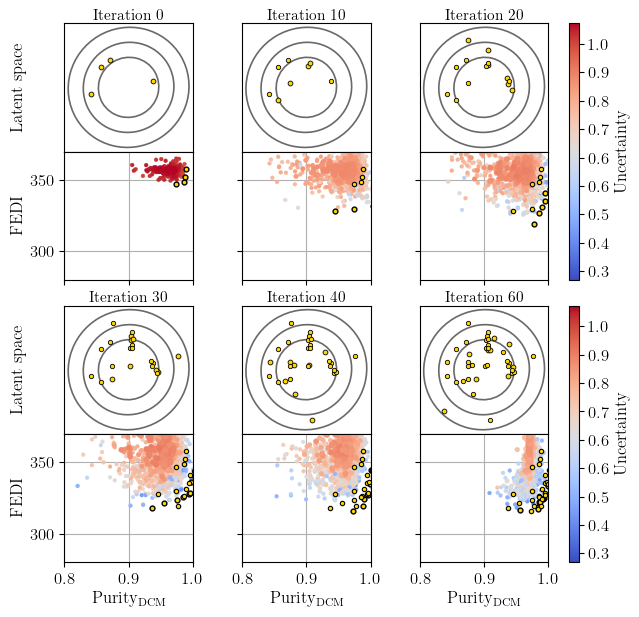

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [7]:
file_df1  = "pareto_front_tracking.csv"
file_df2  = "data_front_tracking.csv"
iterations_sorted =  np.array([1, 11, 21, 31, 41, 61])
vae_model.plot_pareto_front_tracking(file_df1, file_df2 ,
                                      z, iterations_sorted)

# RUN WITH GENETIC ALGORITM 

In [2]:
iterations = 5
# Open Aspen
aspen_file_path1 = "Caso estudio intensificado.bkp"

for iter in tqdm(range(iterations)):
    aspen1 = vae_model.aspen_files(aspen_file_path1)
    # Estar problem
    problem = vae_model.Intensified(aspen1)
    vae_model.run_NSGAII(problem= problem, aspen1=aspen1,
                        aspen_file_path1 = aspen_file_path1,
                        file = r'Intensified_NSGAII', iteration = iter )

  0%|          | 0/5 [00:00<?, ?it/s]

Save data for further analysis

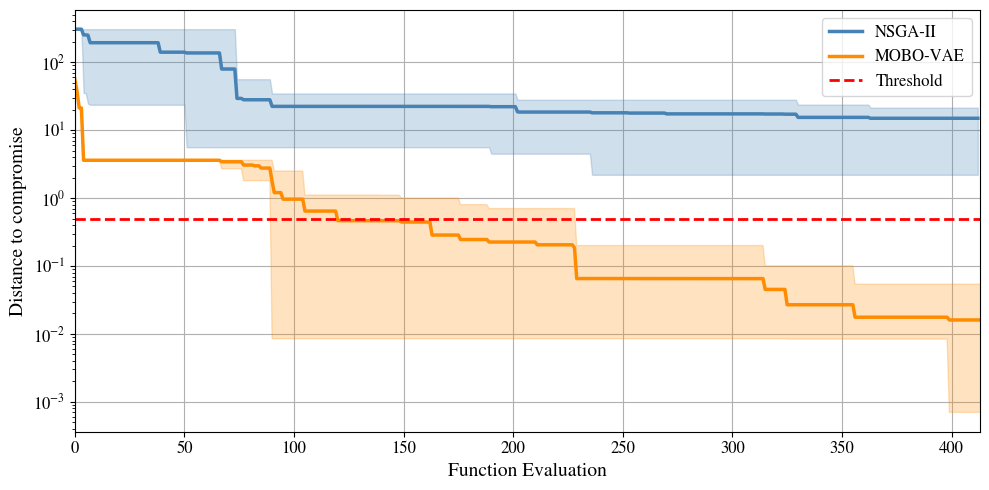

In [1]:
import vae_model
filename_nsga = r"Intensified_NSGAII"
filename_bo = r"Intensified_MOBO_STD"
file_output = "perfomance_curve.pdf"
vae_model.compare_methods(filename_nsga , filename_bo ,
                    file_output)

In [ ]:
# df1 = pd.DataFrame(data= MOBO.all_objectives.numpy() , columns=['pureza', 'FEDI'])
# df2 = pd.DataFrame(data= data_all , columns=['x1','x2','x3','x4','x5', 'x6', 'x7'] )
# df = pd.concat([df1,df2], axis= 1)
# df = df.drop_duplicates()
# df.to_csv(r'Intensified_MOBO.csv', index=False)  